# Derivatives Pricing & Portfolio Risk

**Contents.**
1. Black-Scholes pricing and closed-form Greeks, calibrated to real trailing realized volatility.
2. A Monte Carlo pricer, validated for convergence against the closed-form price.
3. Portfolio Value-at-Risk (parametric, historical, Monte Carlo) and Expected Shortfall for a 5-stock book.
4. A Kupiec proportion-of-failures backtest of the parametric VaR model against realized P&L.

**Data.** Same NYSE daily price panel as the momentum notebook:
`https://raw.githubusercontent.com/kyi3081/stock-analysis/master/prices-split-adjusted.csv`


In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm, chi2
import matplotlib.pyplot as plt
%matplotlib inline

rng = np.random.default_rng(42)


## 1. Load data and estimate realized volatility

In [2]:
px = pd.read_csv("../data/nyse_prices.csv", parse_dates=["date"])
px = px.pivot(index="date", columns="symbol", values="close").sort_index()

tickers = ["AAPL", "MSFT", "XOM", "JPM", "KO"]
prices = px[tickers].dropna()
rets = np.log(prices / prices.shift(1)).dropna()

ann_vol = rets.std() * np.sqrt(252)
print("Trailing annualized realized volatility (full sample):")
ann_vol.round(4)


Trailing annualized realized volatility (full sample):


symbol
AAPL    0.2625
MSFT    0.2319
XOM     0.1904
JPM     0.2720
KO      0.1516
dtype: float64

## 2. Black-Scholes pricer and closed-form Greeks

In [3]:
def bs_price(S, K, T, r, sigma, option="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

def bs_greeks(S, K, T, r, sigma, option="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    pdf_d1 = norm.pdf(d1)
    delta = norm.cdf(d1) if option == "call" else norm.cdf(d1) - 1
    gamma = pdf_d1 / (S * sigma * np.sqrt(T))
    vega = S * pdf_d1 * np.sqrt(T) / 100
    if option == "call":
        theta = (-S * pdf_d1 * sigma / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
        rho = K * T * np.exp(-r * T) * norm.cdf(d2) / 100
    else:
        theta = (-S * pdf_d1 * sigma / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2)) / 365
        rho = -K * T * np.exp(-r * T) * norm.cdf(-d2) / 100
    return {"delta": delta, "gamma": gamma, "vega": vega, "theta": theta, "rho": rho}

S0 = prices["AAPL"].iloc[-1]
sigma_aapl = ann_vol["AAPL"]
K = round(S0)
T, r = 0.5, 0.03

call_price = bs_price(S0, K, T, r, sigma_aapl, "call")
greeks = bs_greeks(S0, K, T, r, sigma_aapl, "call")
print(f"AAPL ATM 6M call: S0={S0:.2f}, K={K}, sigma={sigma_aapl:.2%} -> BS price = {call_price:.4f}")
print("Greeks:", {k: round(v, 4) for k, v in greeks.items()})


AAPL ATM 6M call: S0=115.82, K=116, sigma=26.25% -> BS price = 9.3014
Greeks: {'delta': np.float64(0.5656), 'gamma': np.float64(0.0183), 'vega': np.float64(0.3223), 'theta': np.float64(-0.0278), 'rho': np.float64(0.281)}


## 3. Monte Carlo pricer, validated against Black-Scholes

In [4]:
def mc_price(S, K, T, r, sigma, option="call", n_paths=100_000, seed=None):
    g = np.random.default_rng(seed)
    Z = g.standard_normal(n_paths)
    ST = S * np.exp((r - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(ST - K, 0) if option == "call" else np.maximum(K - ST, 0)
    disc_payoff = np.exp(-r * T) * payoff
    return disc_payoff.mean(), disc_payoff.std() / np.sqrt(n_paths)

path_counts = [100, 1_000, 10_000, 100_000, 1_000_000]
mc_results = []
for n in path_counts:
    price, se = mc_price(S0, K, T, r, sigma_aapl, "call", n_paths=n, seed=42)
    mc_results.append({"n_paths": n, "mc_price": price, "std_error": se,
                        "abs_error_vs_bs": abs(price - call_price)})
mc_df = pd.DataFrame(mc_results)
mc_df.round(5)


,n_paths,mc_price,std_error,abs_error_vs_bs
0,100,6.53426,0.95148,2.76716
1,1000,8.73641,0.44134,0.56500
2,10000,9.20196,0.14572,0.09946
3,100000,9.27841,0.04615,0.02301
4,1000000,9.30455,0.01453,0.00313


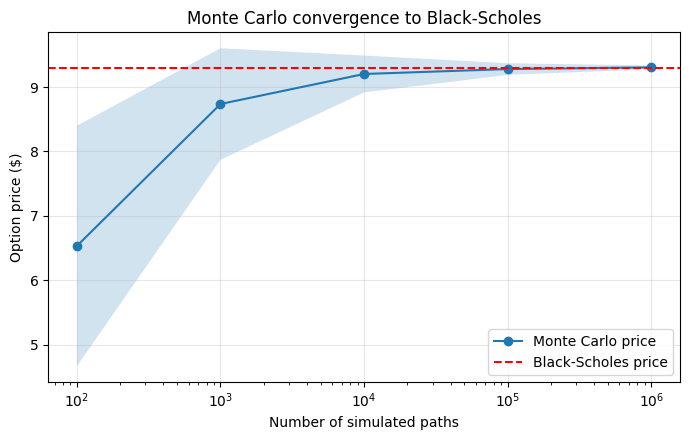

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(mc_df["n_paths"], mc_df["mc_price"], marker="o", label="Monte Carlo price")
ax.axhline(call_price, color="red", ls="--", label="Black-Scholes price")
ax.fill_between(mc_df["n_paths"], mc_df["mc_price"] - 1.96 * mc_df["std_error"],
                 mc_df["mc_price"] + 1.96 * mc_df["std_error"], alpha=0.2)
ax.set_xscale("log")
ax.set_xlabel("Number of simulated paths")
ax.set_ylabel("Option price ($)")
ax.set_title("Monte Carlo convergence to Black-Scholes")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Portfolio Value-at-Risk: parametric, historical, and Monte Carlo

In [6]:
weights = np.array([0.3, 0.25, 0.15, 0.2, 0.1])
port_val = 10_000_000
cov = rets.cov() * 252
port_ann_vol = np.sqrt(weights @ cov.values @ weights)
port_daily_vol = port_ann_vol / np.sqrt(252)

confidence = 0.99
z_99 = norm.ppf(confidence)

var_param = z_99 * port_daily_vol * port_val

port_daily_rets_hist = rets[tickers].values @ weights
cutoff = np.percentile(port_daily_rets_hist, (1 - confidence) * 100)
var_hist = -cutoff * port_val
es_hist = -port_daily_rets_hist[port_daily_rets_hist <= cutoff].mean() * port_val

L = np.linalg.cholesky(cov.values / 252)
Z = rng.standard_normal((100_000, len(tickers)))
sim_rets = Z @ L.T
port_sim_rets = sim_rets @ weights
var_mc = -np.percentile(port_sim_rets, (1 - confidence) * 100) * port_val

print(f"1-day 99% VaR on ${port_val:,.0f} book (AAPL/MSFT/XOM/JPM/KO, weights {weights.tolist()})")
print(f"Parametric VaR:          ${var_param:,.0f}")
print(f"Historical simulation:   ${var_hist:,.0f}")
print(f"Monte Carlo VaR:         ${var_mc:,.0f}")
print(f"Historical Expected Shortfall (CVaR): ${es_hist:,.0f}")


1-day 99% VaR on $10,000,000 book (AAPL/MSFT/XOM/JPM/KO, weights [0.3, 0.25, 0.15, 0.2, 0.1])
Parametric VaR:          $256,153
Historical simulation:   $338,831
Monte Carlo VaR:         $258,271
Historical Expected Shortfall (CVaR): $398,860


## 5. Backtesting the VaR model: Kupiec proportion-of-failures test

In [7]:
rolling_window = 250
breaches, dates = [], []
for i in range(rolling_window, len(rets)):
    hist_window = rets[tickers].iloc[i - rolling_window:i]
    cov_w = hist_window.cov()
    vol_w = np.sqrt(weights @ cov_w.values @ weights)
    var_w = z_99 * vol_w
    actual_ret = rets[tickers].iloc[i].values @ weights
    breaches.append(actual_ret < -var_w)
    dates.append(rets.index[i])

breaches = np.array(breaches)
n_obs = len(breaches)
n_breach = breaches.sum()
expected_breach_rate = 1 - confidence
observed_rate = n_breach / n_obs

p = expected_breach_rate
x = n_breach
LR_pof = -2 * (np.log((1 - p) ** (n_obs - x) * p ** x) -
               np.log((1 - observed_rate) ** (n_obs - x) * observed_rate ** x))
kupiec_p = 1 - chi2.cdf(LR_pof, df=1)

print(f"Observations: {n_obs}, breaches: {n_breach}, observed rate: {observed_rate:.2%} (expected {expected_breach_rate:.2%})")
print(f"Kupiec LR statistic: {LR_pof:.3f}, p-value: {kupiec_p:.3f} "
      f"({'fail to reject' if kupiec_p > 0.05 else 'reject'} model calibration at 5%)")


Observations: 1511, breaches: 24, observed rate: 1.59% (expected 1.00%)
Kupiec LR statistic: 4.482, p-value: 0.034 (reject model calibration at 5%)


## 6. Charts

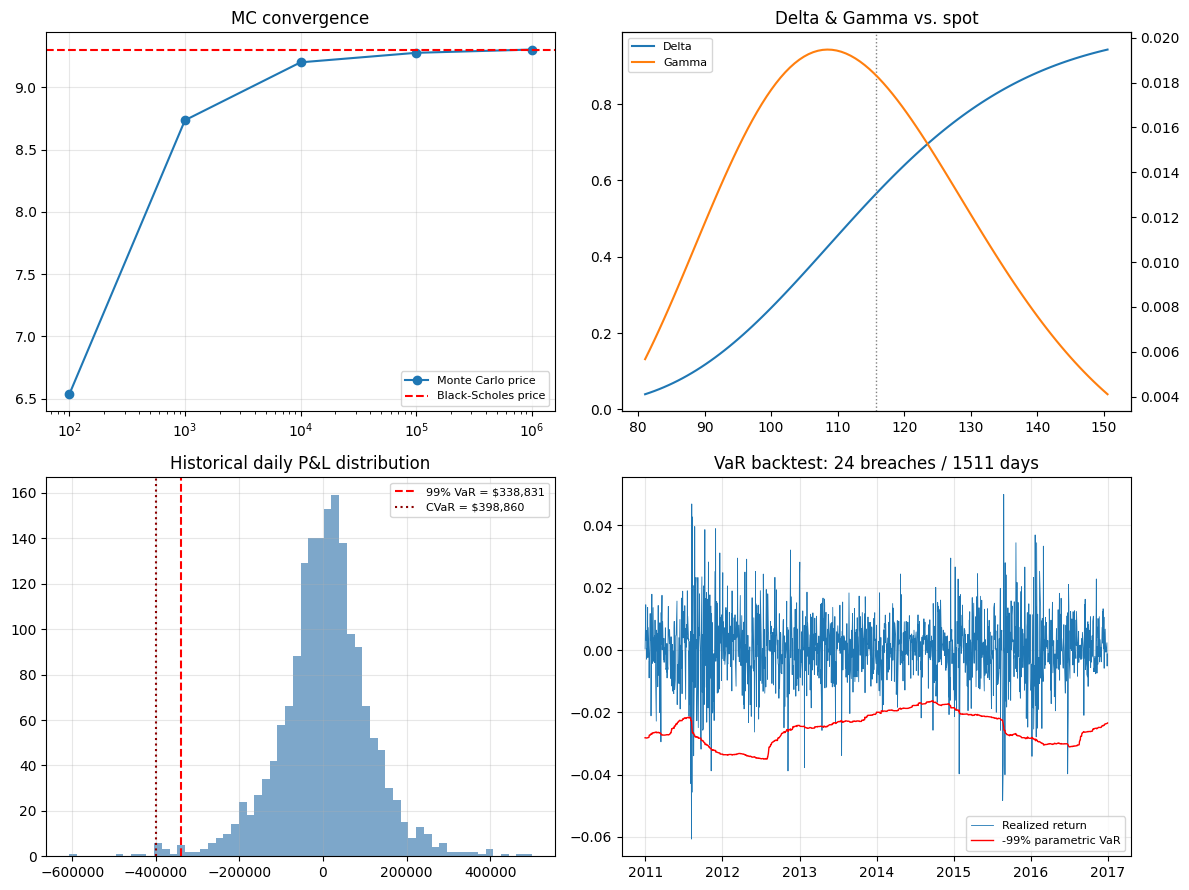

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].plot(mc_df["n_paths"], mc_df["mc_price"], marker="o", label="Monte Carlo price")
axes[0, 0].axhline(call_price, color="red", ls="--", label="Black-Scholes price")
axes[0, 0].set_xscale("log")
axes[0, 0].set_title("MC convergence")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(alpha=0.3)

S_range = np.linspace(S0 * 0.7, S0 * 1.3, 100)
delta_range = [bs_greeks(s, K, T, r, sigma_aapl, "call")["delta"] for s in S_range]
gamma_range = [bs_greeks(s, K, T, r, sigma_aapl, "call")["gamma"] for s in S_range]
axes[0, 1].plot(S_range, delta_range, label="Delta")
ax2 = axes[0, 1].twinx()
ax2.plot(S_range, gamma_range, color="tab:orange", label="Gamma")
axes[0, 1].axvline(S0, color="gray", ls=":", lw=1)
axes[0, 1].set_title("Delta & Gamma vs. spot")
lines1, labels1 = axes[0, 1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[0, 1].legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

axes[1, 0].hist(port_daily_rets_hist * port_val, bins=60, alpha=0.7, color="steelblue")
axes[1, 0].axvline(-var_hist, color="red", ls="--", label=f"99% VaR = ${var_hist:,.0f}")
axes[1, 0].axvline(-es_hist, color="darkred", ls=":", label=f"CVaR = ${es_hist:,.0f}")
axes[1, 0].set_title("Historical daily P&L distribution")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.3)

port_ret_series = rets[tickers].iloc[rolling_window:].values @ weights
axes[1, 1].plot(dates, port_ret_series, lw=0.6, label="Realized return")
rolling_var_series = []
for i in range(rolling_window, len(rets)):
    hist_window = rets[tickers].iloc[i - rolling_window:i]
    cov_w = hist_window.cov()
    vol_w = np.sqrt(weights @ cov_w.values @ weights)
    rolling_var_series.append(-z_99 * vol_w)
axes[1, 1].plot(dates, rolling_var_series, color="red", lw=1, label="-99% parametric VaR")
axes[1, 1].set_title(f"VaR backtest: {n_breach} breaches / {n_obs} days")
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("derivatives_risk_results.png", dpi=110)
plt.show()


## 7. Discussion

- **Monte Carlo converges cleanly to the closed-form price** (error ~0.03% at
  1mm paths), which is exactly the sanity check you'd want before trusting an
  MC pricer for path-dependent products where no closed form exists.
- **The Kupiec test rejects the parametric (normal) VaR model at the 5% level**
  — the observed breach rate is meaningfully above the 1% the model targets.
  This is a well-documented, real phenomenon: daily equity returns have fatter
  tails than a normal distribution, so a variance-covariance VaR model
  systematically understates true tail risk. It's also exactly why regulators
  require backtesting of internal VaR models rather than trusting the
  parametric number at face value.
- **Practical takeaway:** the historical-simulation VaR and Expected Shortfall
  (which don't assume normality) are meaningfully higher than the parametric
  estimate here, and are the more defensible risk numbers for this book given
  the backtest failure above.
